# Unsuperivised Clustering
## Project Description
In this project, you will use a clustering algorithm to perform customer segmentation on a dataset by dividing customers into groups based on similar characteristics, such as purchasing behavior or demographics. By segmenting customers, businesses can gain valuable insights to tailor their marketing strategies, product offerings, and customer service.

### Importing resources

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as mn
import seaborn as sns

In [72]:
df = pd.read_csv(r"./marketing_campaign.csv")

print("Dataset read into df")

df.head()

Dataset read into df


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04/09/2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08/03/2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21/08/2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10/02/2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19/01/2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## Cleaning & Prep

In [111]:
print(df.shape)
print(df.dtypes)
print(df.columns.tolist())

# Check for fully duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Check for duplicate IDs specifically (if there's an ID column)
print("Duplicate IDs:", df['ID'].duplicated().sum())

(2240, 27)
ID                                str
Year_Birth             datetime64[us]
Education                         str
Marital_Status                    str
Income                        float64
Kidhome                         int64
Teenhome                        int64
Dt_Customer            datetime64[us]
Recency                         int64
MntWines                        int64
MntFruits                       int64
MntMeatProducts                 int64
MntFishProducts                 int64
MntSweetProducts                int64
MntGoldProds                    int64
NumDealsPurchases               int64
NumWebPurchases                 int64
NumCatalogPurchases             int64
NumStorePurchases               int64
NumWebVisitsMonth               int64
AcceptedCmp3                    int64
AcceptedCmp4                    int64
AcceptedCmp5                    int64
AcceptedCmp1                    int64
AcceptedCmp2                    int64
Complain                        int64
R

### Meaningful data types

In [73]:
print("Original dtypes:")
print(df.dtypes)

df['ID'] = df['ID'].astype(str)
df['Year_Birth'] = pd.to_datetime(df['Year_Birth'], format='%Y')
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d/%m/%Y')

print("\nAfter conversion:")
print(df.dtypes)

Original dtypes:
ID                       int64
Year_Birth               int64
Education                  str
Marital_Status             str
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer                str
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

After conversion:
ID                                str
Year_Birth   

## EDA

### Missingness

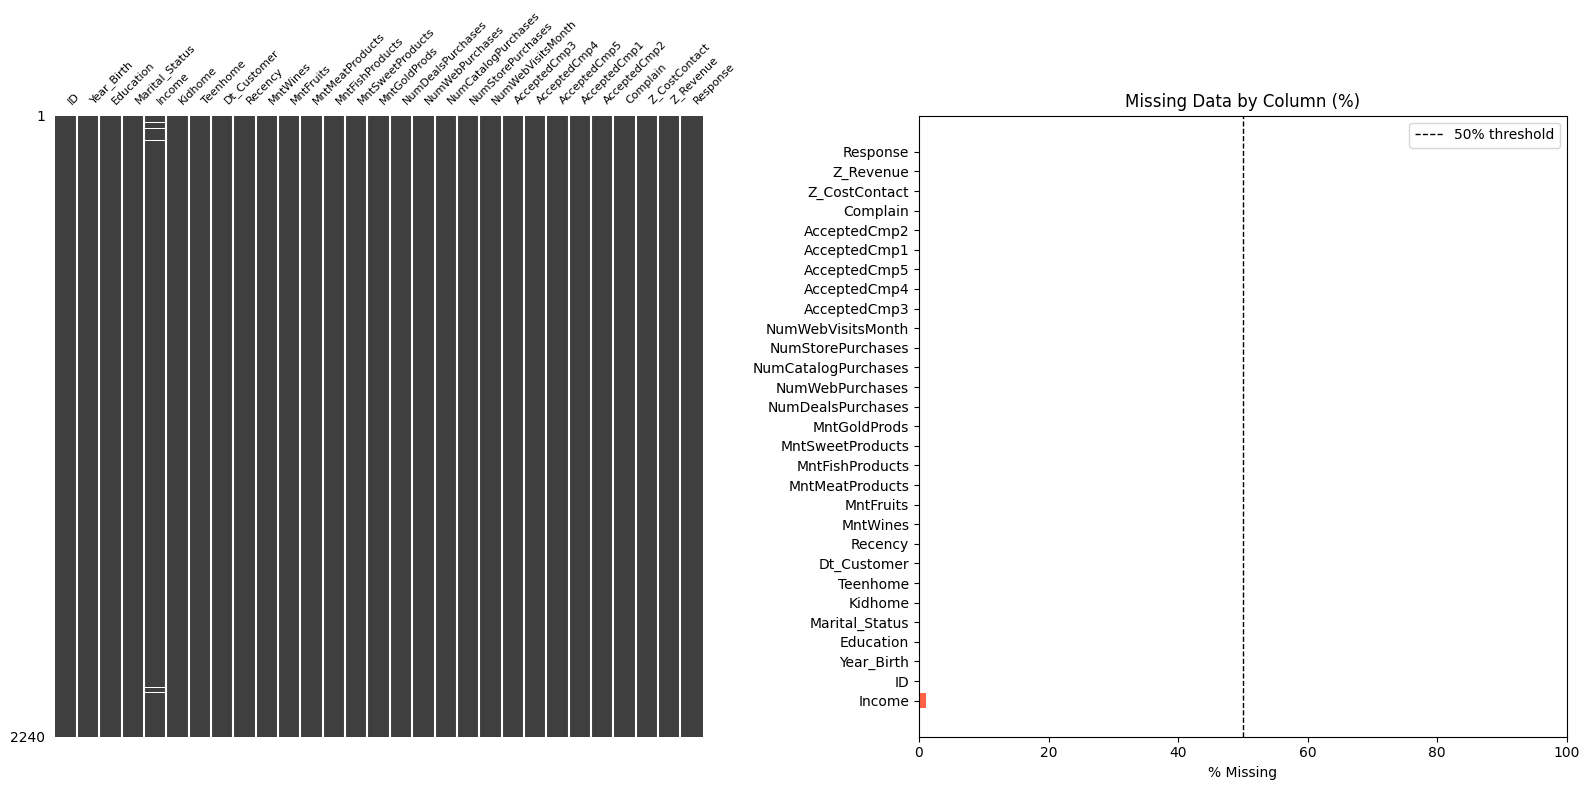

In [74]:
miss_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

fig, axs = plt.subplots(1, 2, figsize=(16,8))

# axs 1: missingno matrix
mn.matrix(df, ax=axs[0], sparkline=False, fontsize=8)

# axs 2: missing % bar chart
axs[1].barh(miss_pct.index, # column names
            miss_pct.values,    # missingness % of each column
            color = 'tomato')
axs[1].set_xlabel('% Missing')
axs[1].set_xlim(0,100)
axs[1].set_title('Missing Data by Column (%)')
axs[1].axvline(50, color='black', linestyle='--', linewidth=1, label='50% threshold')
axs[1].legend()

plt.tight_layout()
plt.show()

In [75]:
incomplete_columns = list(df.columns[df.isnull().any()])

for col in incomplete_columns:
    num_missing = df[df[col].isnull() == True].shape[0]
    print(f"values missing for column '{col}': {num_missing}")

values missing for column 'Income': 24


In [ ]:
# there is no pattern to the missing income rows & filling with 0 would bias the model
# decided to drop the 24 rows with missing income

df.dropna(axis=0, inplace=True)

### Distributions

In [94]:
df.nunique()

ID                     2240
Year_Birth               59
Education                 5
Marital_Status            8
Income                 1974
Kidhome                   3
Teenhome                  3
Dt_Customer             663
Recency                 100
MntWines                776
MntFruits               158
MntMeatProducts         558
MntFishProducts         182
MntSweetProducts        177
MntGoldProds            213
NumDealsPurchases        15
NumWebPurchases          15
NumCatalogPurchases      14
NumStorePurchases        14
NumWebVisitsMonth        16
AcceptedCmp3              2
AcceptedCmp4              2
AcceptedCmp5              2
AcceptedCmp1              2
AcceptedCmp2              2
Complain                  2
Z_CostContact             1
Z_Revenue                 1
Response                  2
dtype: int64

In [95]:
# since Z_CostContact and Z_Revenue columns both only have 1 value, drop them

df.drop(columns=['Z_CostContact', 'Z_Revenue'], inplace=True)
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957-01-01,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,0,0,0,0,0,1
1,2174,1954-01-01,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,0,0,0,0,0
2,4141,1965-01-01,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,0,0,0,0,0
3,6182,1984-01-01,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,0,0,0,0,0
4,5324,1981-01-01,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,0,0,0,0,0


In [102]:
id_cols = ['ID']
date_cols = ['Year_Birth', 'Dt_Customer']
binary_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'Response', 'Complain']
continuous_cols = [col for col in df.select_dtypes(include='number').columns
                   if col not in binary_cols + id_cols]

In [97]:
df[continuous_cols].describe()  # stats for continuous

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
count,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518
std,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000
50%,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000
75%,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000
max,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000


In [98]:
df[binary_cols].mean()  # acceptance rates for binary

AcceptedCmp1    0.064286
AcceptedCmp2    0.013393
AcceptedCmp3    0.072768
AcceptedCmp4    0.074554
AcceptedCmp5    0.072768
Response        0.149107
Complain        0.009375
dtype: float64

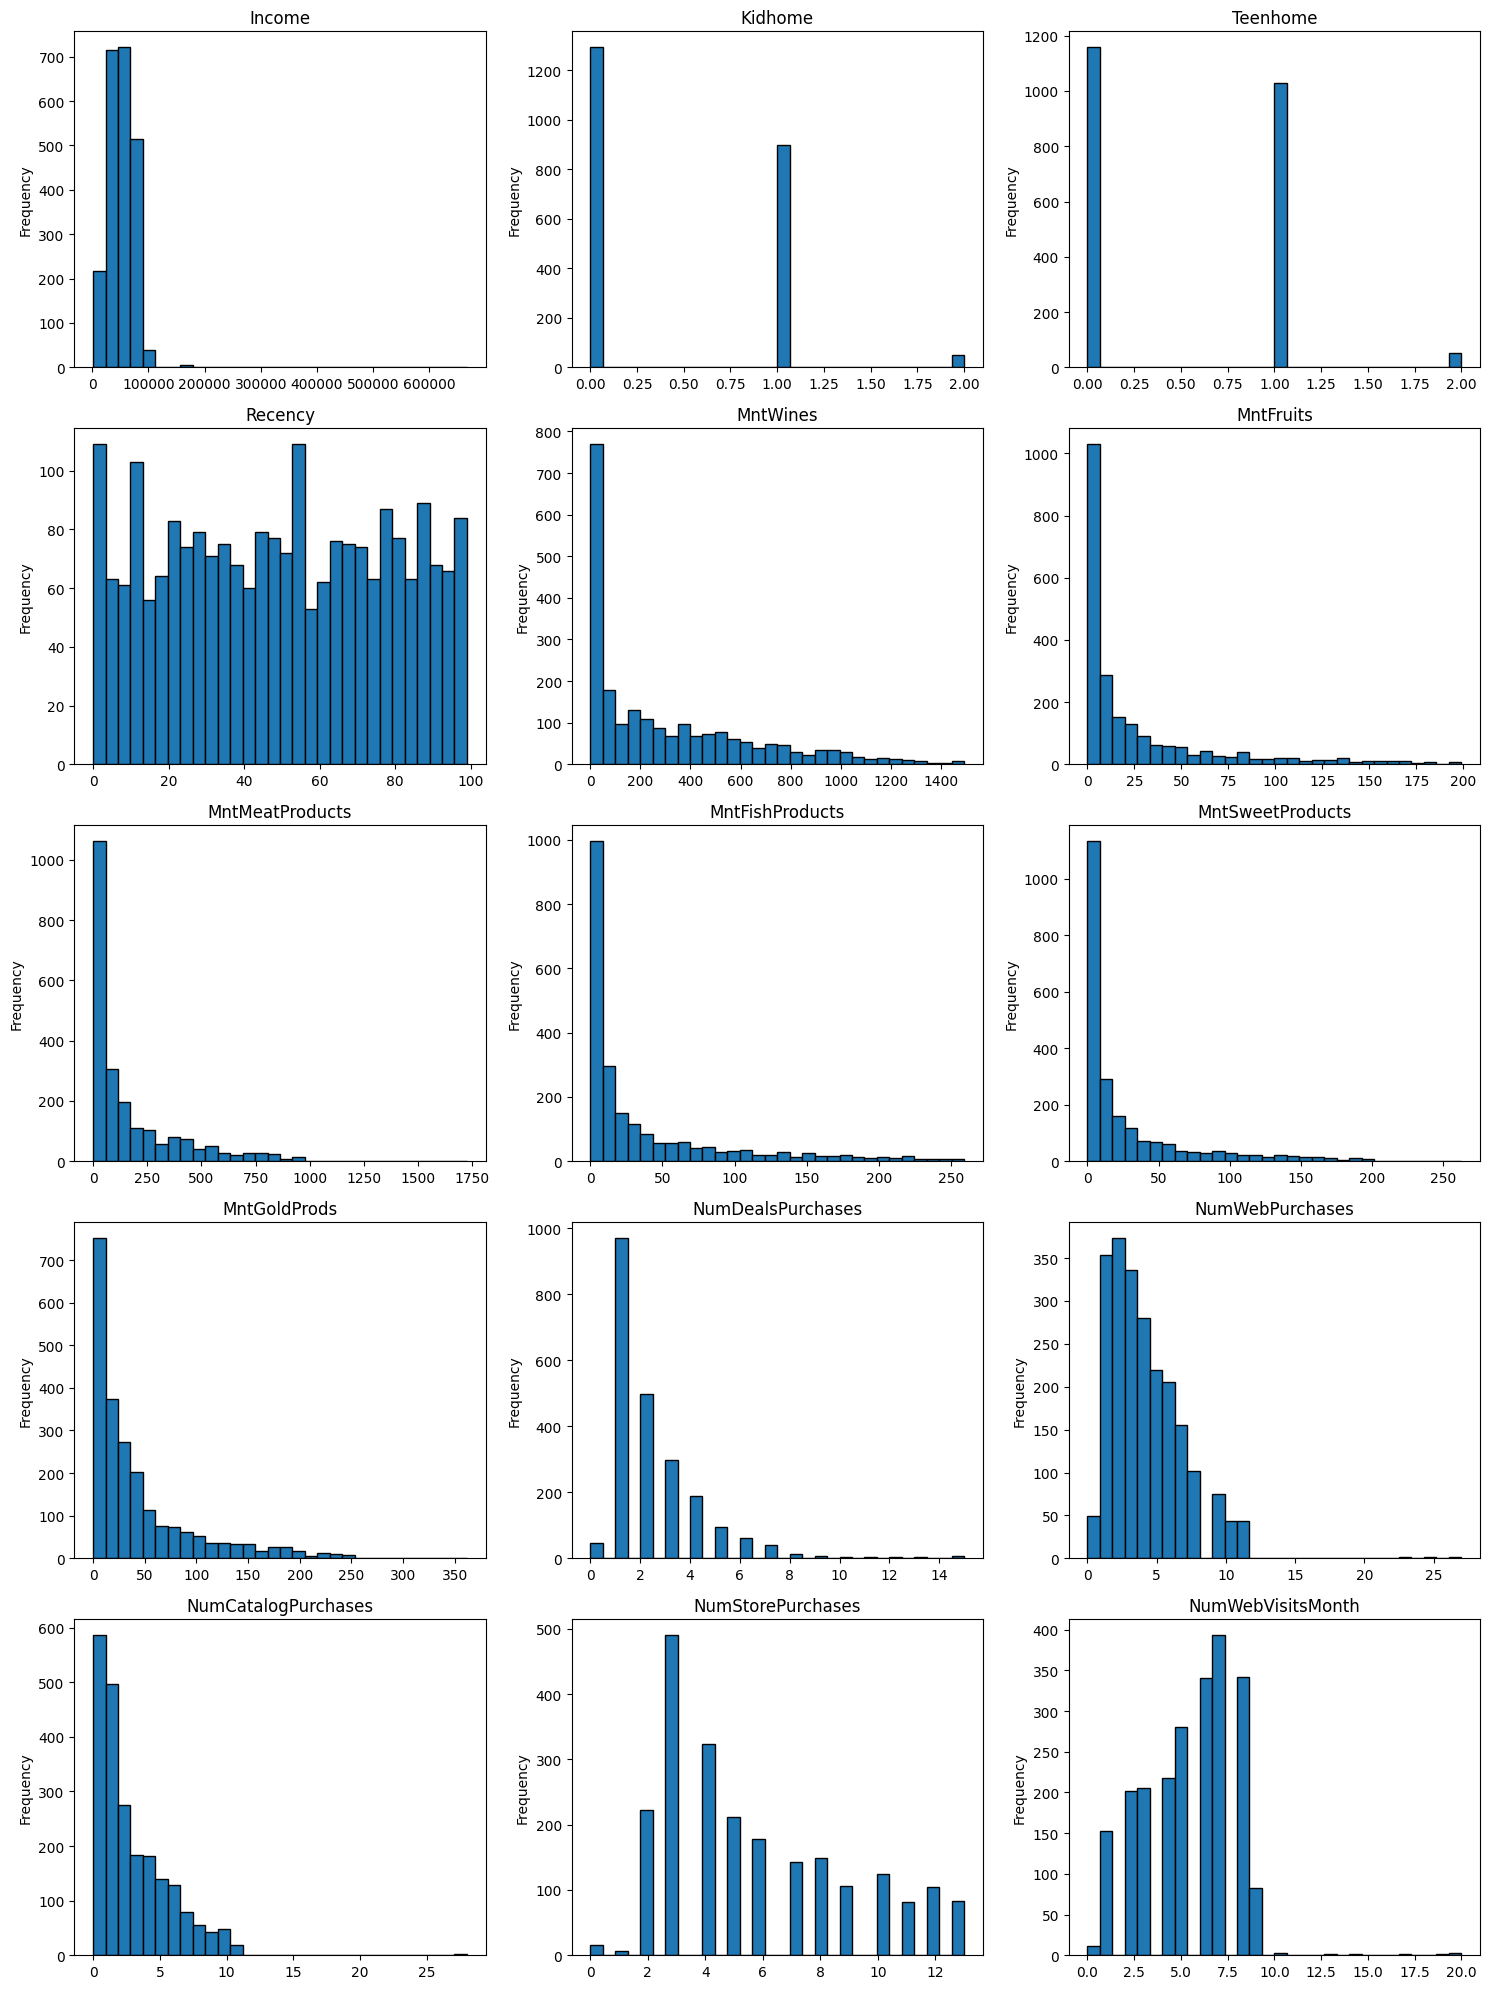

In [107]:
# Calculate grid size dynamically based on number of columns
n_cols = 3
n_rows = (len(continuous_cols) + n_cols - 1) // n_cols  # rounds up

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    axes[i].hist(df[col], bins=30, edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

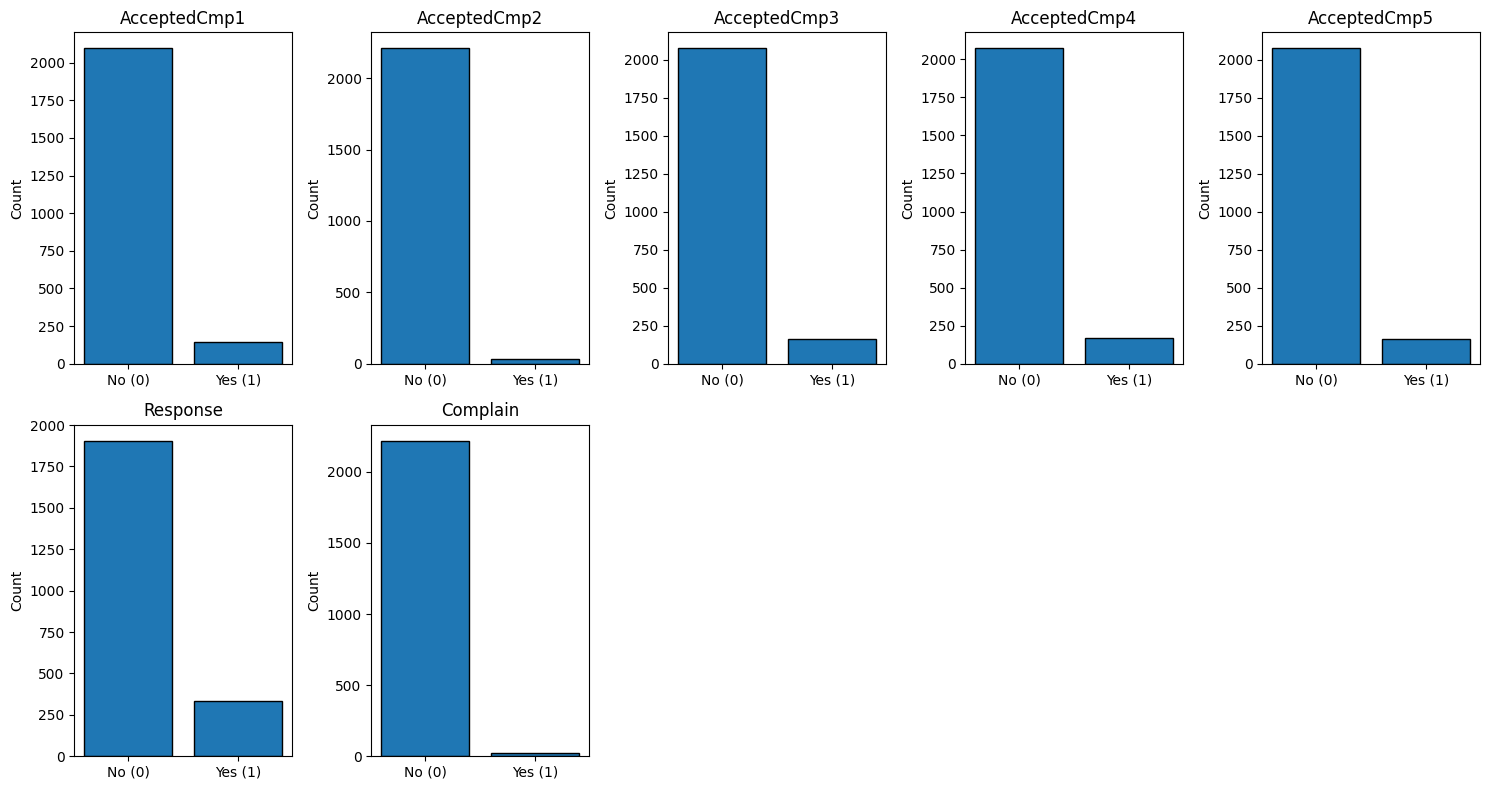

In [106]:
n_cols = 5
n_rows = (len(binary_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(binary_cols):
    counts = df[col].value_counts().sort_index()
    axes[i].bar(['No (0)', 'Yes (1)'], counts.values, edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

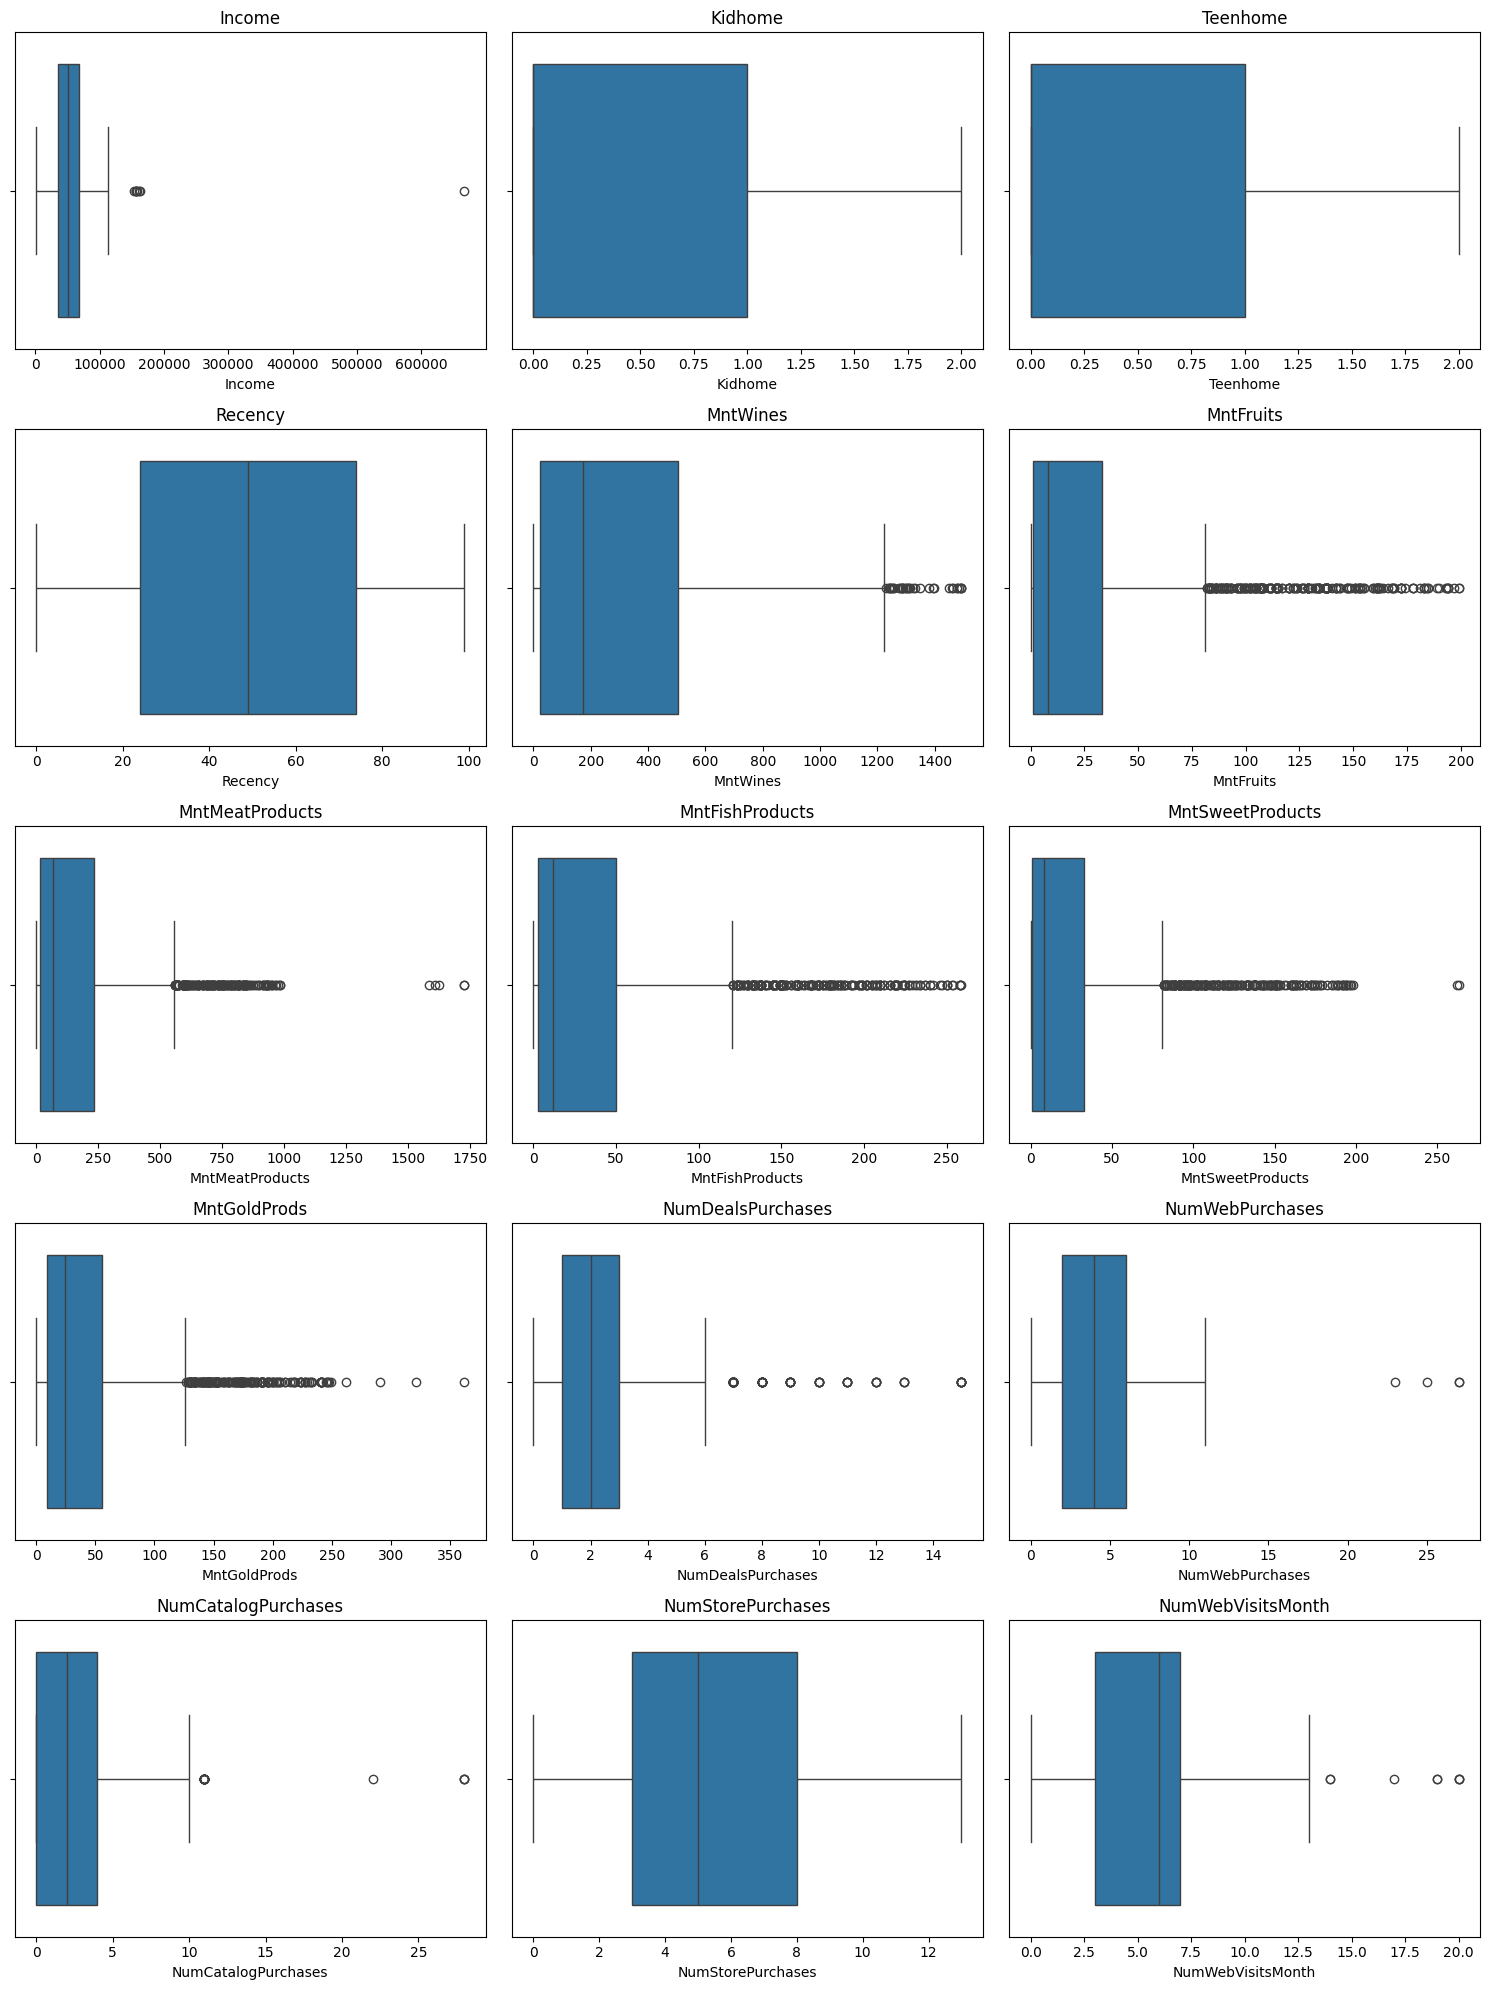

In [110]:
n_cols = 3
n_rows = (len(continuous_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
cat_cols = df.select_dtypes(include="str")